# 04. Guardrail Metrics and Multiple Testing

Product experiments rarely have one metric. A new feature might increase revenue, reduce latency, increase support tickets, change retention, move clicks, affect different countries differently, and produce dozens of diagnostic metric shifts. This is good because a product is a system. It is dangerous because every extra metric gives noise another chance to look meaningful.

This notebook is about two related problems:

1. **Guardrail metrics**: metrics that protect the product, user experience, platform, or business from harmful side effects.
2. **Multiple testing**: the inflation of false positives when many metrics, segments, variants, or time windows are tested.

The central idea is:

> A trustworthy experiment readout needs a metric hierarchy and an error-control strategy.

Without that structure, experiment analysis can become post-hoc storytelling: pick the metric that moved, pick the segment that looks exciting, and rationalize the result after the fact.

We will simulate how false positives accumulate, implement common multiple-testing corrections, and build a product experiment readout that separates primary metrics, guardrails, invariant checks, and exploratory diagnostics.

## Learning Goals

By the end of this notebook, you should be able to:

- Distinguish primary, secondary, guardrail, invariant, and diagnostic metrics.
- Explain why multiple testing inflates false-positive risk.
- Compute familywise error rate for many tests.
- Implement Bonferroni, Holm-style step-down control, and Benjamini-Hochberg false discovery rate control.
- Explain the difference between familywise error rate and false discovery rate.
- Build launch rules using primary metric thresholds and guardrail tolerances.
- Simulate metric shopping and segment fishing.
- Treat exploratory metric movements differently from confirmatory evidence.
- Create an experiment readout that is useful for product decisions without overclaiming.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "primary": "#d7ecff",
    "guardrail": "#ffe0c2",
    "invariant": "#dff0d8",
    "diagnostic": "#eadcf8",
    "warning": "#fff1c7",
    "decision": "#ffd6db",
    "neutral": "#f7f7f7",
}

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Create a Graphviz diagram with consistent lecture styling."""
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.65")
    dot.attr("node", shape="box", style="rounded,filled", color="#2b2b2b", fontname="Helvetica", fontsize="11", margin="0.12,0.08")
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            attrs = {}
        else:
            src, dst, attrs = edge
        dot.edge(src, dst, **attrs)
    return dot


def two_sample_summary(y, z):
    y = np.asarray(y)
    z = np.asarray(z)
    y1 = y[z == 1]
    y0 = y[z == 0]
    diff = y1.mean() - y0.mean()
    se = np.sqrt(y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0))
    z_stat = diff / se
    p_two_sided = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return diff, se, p_two_sided


def bonferroni_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    return np.minimum(p * len(p), 1.0)


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    sorted_p = p[order]
    adjusted_sorted = np.maximum.accumulate((m - np.arange(m)) * sorted_p)
    adjusted_sorted = np.minimum(adjusted_sorted, 1.0)
    adjusted = np.empty(m)
    adjusted[order] = adjusted_sorted
    return adjusted


def bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    sorted_p = p[order]
    adjusted_sorted = sorted_p * m / np.arange(1, m + 1)
    adjusted_sorted = np.minimum.accumulate(adjusted_sorted[::-1])[::-1]
    adjusted_sorted = np.minimum(adjusted_sorted, 1.0)
    adjusted = np.empty(m)
    adjusted[order] = adjusted_sorted
    return adjusted


def bh_reject(p_values, q=0.05):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    sorted_p = p[order]
    thresholds = q * np.arange(1, m + 1) / m
    passed = sorted_p <= thresholds
    reject = np.zeros(m, dtype=bool)
    if passed.any():
        k = np.max(np.where(passed)[0])
        reject[order[: k + 1]] = True
    return reject


def make_metric_result(metric, role, diff, se, p_value, higher_is_better=True, practical_threshold=None, guardrail_tolerance=None):
    return {
        "metric": metric,
        "role": role,
        "difference": diff,
        "std_error": se,
        "ci_lower": diff - 1.96 * se,
        "ci_upper": diff + 1.96 * se,
        "p_value": p_value,
        "higher_is_better": higher_is_better,
        "practical_threshold": practical_threshold,
        "guardrail_tolerance": guardrail_tolerance,
    }

## 1. Metric Roles in Product Experiments

A mature experiment readout assigns each metric a role before analysis.

| Role | Question | Example | How to use it |
|---|---|---|---|
| Primary | Did the feature accomplish the main goal? | 14-day value, retention, conversion | Main decision metric |
| Secondary | How did behavior change? | activation, click-through, search depth | Mechanism and diagnosis |
| Guardrail | Did we harm something important? | latency, errors, support tickets, refunds | Launch constraint |
| Invariant | Did randomization/logging behave? | pre-experiment value, country mix, assignment counts | Quality check |
| Diagnostic | Where should we investigate next? | segment metrics, funnel steps, exploratory metrics | Hypothesis generation |

Guardrails are not merely secondary metrics with a scarier name. They are pre-specified constraints. A feature can win on the primary metric and still fail the launch decision if it damages a guardrail.

Metric models for online controlled experiments emphasize that measurement choices shape the meaning and trustworthiness of product decisions (Kohavi et al., 2008; Mattos et al., 2018).

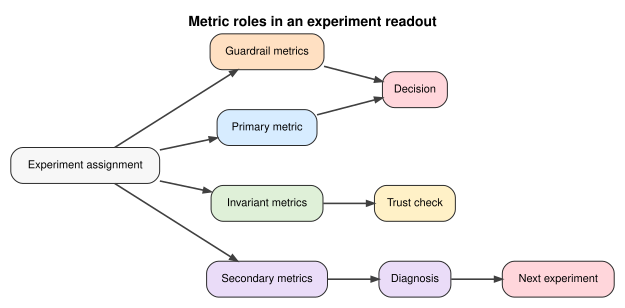

In [3]:
metric_edges = [
    ("Experiment assignment", "Primary metric"),
    ("Experiment assignment", "Secondary metrics"),
    ("Experiment assignment", "Guardrail metrics"),
    ("Experiment assignment", "Invariant metrics"),
    ("Primary metric", "Decision"),
    ("Guardrail metrics", "Decision"),
    ("Invariant metrics", "Trust check"),
    ("Secondary metrics", "Diagnosis"),
    ("Diagnosis", "Next experiment"),
]
metric_colors = {
    "Experiment assignment": COLORS["neutral"],
    "Primary metric": COLORS["primary"],
    "Secondary metrics": COLORS["diagnostic"],
    "Guardrail metrics": COLORS["guardrail"],
    "Invariant metrics": COLORS["invariant"],
    "Decision": COLORS["decision"],
    "Trust check": COLORS["warning"],
    "Diagnosis": COLORS["diagnostic"],
    "Next experiment": COLORS["decision"],
}

display(make_dag(metric_edges, "Metric roles in an experiment readout", metric_colors))

### Interpretation

The primary metric and guardrails both feed the launch decision. Invariant metrics do something different: they test whether the experiment data can be trusted. Secondary and diagnostic metrics help explain the result and create hypotheses for future work.

This separation prevents a common failure mode: a team sees one favorable diagnostic metric and treats it as if it were the original decision metric.

## 2. Why Multiple Testing Creates False Positives

Suppose every null hypothesis is true and every test uses $\alpha = 0.05$. One test has a 5% false-positive probability. But if we run many independent tests, the probability of at least one false positive is:

$$
1 - (1 - \alpha)^m,
$$

where $m$ is the number of tests.

With 20 metrics, the chance of at least one false positive is much larger than 5%. This is the basic multiplicity problem.

In [4]:
alpha = 0.05
m_values = np.arange(1, 101)
fwer_formula = 1 - (1 - alpha) ** m_values

fwer_table = pd.DataFrame({
    "number_of_tests": [1, 5, 10, 20, 50, 100],
})
fwer_table["prob_at_least_one_false_positive"] = 1 - (1 - alpha) ** fwer_table["number_of_tests"]
fwer_table.round(3)

,number_of_tests,prob_at_least_one_false_positive
0,1,0.050
1,5,0.226
2,10,0.401
3,20,0.642
4,50,0.923
5,100,0.994


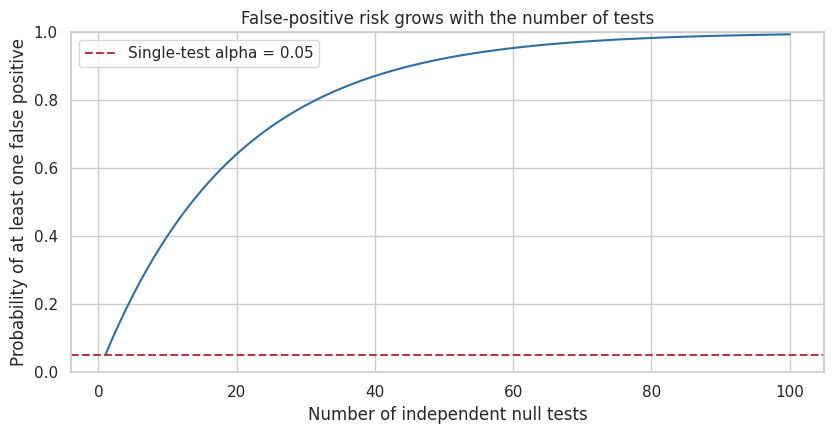

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.lineplot(x=m_values, y=fwer_formula, color="#2f6f9f", ax=ax)
ax.axhline(0.05, color="#b23a48", linestyle="--", label="Single-test alpha = 0.05")
ax.set_title("False-positive risk grows with the number of tests")
ax.set_xlabel("Number of independent null tests")
ax.set_ylabel("Probability of at least one false positive")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

With enough metrics, segments, and time windows, something will look significant by chance. This does not mean we should ignore rich experiment telemetry. It means we need to classify metrics and control error rates according to the role of each analysis.

## 3. Simulating Metric Shopping Under the Global Null

Let us simulate experiments where the treatment has no effect on any metric. If an analyst tests many metrics and reports the one with the smallest p-value, they can easily create a compelling but false story.

In [6]:
def simulate_null_metric_shopping(n_experiments=5_000, n_metrics=30, alpha=0.05, seed=1):
    rng_local = np.random.default_rng(seed)
    # Under valid null tests, p-values are Uniform(0, 1). This is enough to study multiplicity.
    p = rng_local.uniform(size=(n_experiments, n_metrics))
    min_p = p.min(axis=1)
    any_sig = (p < alpha).any(axis=1)
    count_sig = (p < alpha).sum(axis=1)
    return pd.DataFrame({
        "min_p_value": min_p,
        "any_significant": any_sig,
        "number_significant": count_sig,
    })

null_shopping = simulate_null_metric_shopping()

pd.DataFrame({
    "quantity": [
        "Simulated probability of at least one p < 0.05",
        "Formula probability for 30 independent tests",
        "Average number of p < 0.05 metrics",
        "Median minimum p-value",
    ],
    "value": [
        null_shopping["any_significant"].mean(),
        1 - (1 - 0.05) ** 30,
        null_shopping["number_significant"].mean(),
        null_shopping["min_p_value"].median(),
    ],
}).round(4)

,quantity,value
0,Simulated probability of at least one p < 0.05,0.7808
1,Formula probability for 30 independent tests,0.7854
2,Average number of p < 0.05 metrics,1.4928
3,Median minimum p-value,0.0227


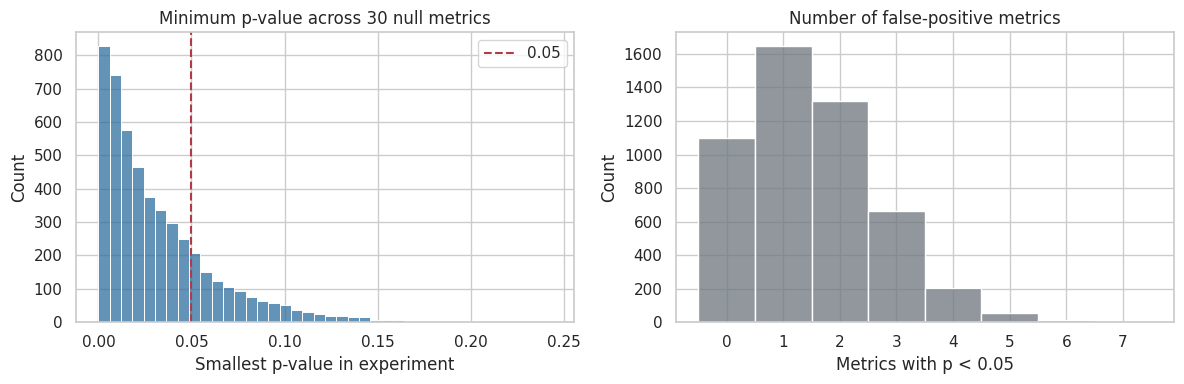

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(null_shopping["min_p_value"], bins=40, color="#2f6f9f", ax=axes[0])
axes[0].axvline(0.05, color="#b23a48", linestyle="--", label="0.05")
axes[0].set_title("Minimum p-value across 30 null metrics")
axes[0].set_xlabel("Smallest p-value in experiment")
axes[0].legend()

sns.histplot(null_shopping["number_significant"], bins=np.arange(-0.5, 8.5, 1), color="#6c757d", ax=axes[1])
axes[1].set_title("Number of false-positive metrics")
axes[1].set_xlabel("Metrics with p < 0.05")

plt.tight_layout()
plt.show()

### Interpretation

Even when every treatment effect is zero, many experiments show at least one metric with $p < 0.05$. If the analyst reports only that metric, the readout becomes misleading.

This is why the primary metric should be declared before the experiment. Exploratory metrics can still be useful, but they should be labeled as exploratory and ideally confirmed in a future experiment.

## 4. Error Rates: FWER Versus FDR

There are several ways to define and control error from many tests.

### Familywise Error Rate

The familywise error rate, or FWER, is the probability of making at least one false rejection in a family of tests:

$$
FWER = P(V \ge 1),
$$

where $V$ is the number of false discoveries.

FWER control is strict. It is useful when any false positive is costly, such as a primary metric family, safety outcomes, or formal confirmatory claims.

### False Discovery Rate

The false discovery rate, or FDR, is the expected fraction of discoveries that are false:

$$
FDR = E\left[\frac{V}{R}\right],
$$

with the fraction defined as zero when there are no discoveries. The Benjamini-Hochberg procedure introduced a practical approach to FDR control and is less conservative than FWER control in many settings (Benjamini & Hochberg, 1995; Thissen et al., 2002).

FDR control is often more appropriate for exploratory families where some false leads are acceptable as long as the discovery list is not dominated by noise.

In [8]:
error_rate_table = pd.DataFrame({
    "error_control_goal": ["No false positives in the family", "Limit the fraction of false discoveries"],
    "formal_quantity": ["FWER = P(V >= 1)", "FDR = E[V / max(R, 1)]"],
    "common_methods": ["Bonferroni, Holm", "Benjamini-Hochberg"],
    "good_for": [
        "Primary confirmatory families, safety-critical guardrails",
        "Exploratory metric families, discovery workflows, segment scans",
    ],
    "tradeoff": ["More conservative, lower power", "More discoveries, accepts controlled false-discovery risk"],
})
error_rate_table

,error_control_goal,formal_quantity,common_methods,good_for,tradeoff
0,No false positives in the family,FWER = P(V >= 1),"Bonferroni, Holm","Primary confirmatory families, safety-critical...","More conservative, lower power"
1,Limit the fraction of false discoveries,"FDR = E[V / max(R, 1)]",Benjamini-Hochberg,"Exploratory metric families, discovery workflo...","More discoveries, accepts controlled false-dis..."


## 5. Bonferroni, Holm, and Benjamini-Hochberg

We will compare three common correction methods.

### Bonferroni

Bonferroni controls FWER by testing each p-value against $\alpha / m$, or equivalently multiplying each p-value by $m$.

### Holm Step-Down

Holm-style procedures are sequentially rejective and usually less conservative than simple Bonferroni while controlling familywise error. The p-values are sorted from smallest to largest and compared to increasingly permissive thresholds. Sequential Bonferroni procedures are discussed in the multiple-comparison literature (Donoghue, 2004; Verhoeven et al., 2005).

### Benjamini-Hochberg

Benjamini-Hochberg sorts p-values and finds the largest rank $k$ such that:

$$
p_{(k)} \le \frac{k}{m}q,
$$

where $q$ is the target FDR level. It rejects all hypotheses up to that rank.

In [9]:
example_p = np.array([0.001, 0.008, 0.018, 0.032, 0.049, 0.071, 0.12, 0.20, 0.44, 0.81])
example_adjusted = pd.DataFrame({
    "metric": [f"metric_{i+1}" for i in range(len(example_p))],
    "raw_p": example_p,
    "bonferroni_p": bonferroni_adjust(example_p),
    "holm_p": holm_adjust(example_p),
    "bh_q_value": bh_adjust(example_p),
})
example_adjusted["raw_reject_0.05"] = example_adjusted["raw_p"] < 0.05
example_adjusted["bonferroni_reject_0.05"] = example_adjusted["bonferroni_p"] < 0.05
example_adjusted["holm_reject_0.05"] = example_adjusted["holm_p"] < 0.05
example_adjusted["bh_reject_q_0.05"] = bh_reject(example_p, q=0.05)
example_adjusted.round(4)

,metric,raw_p,bonferroni_p,holm_p,bh_q_value,raw_reject_0.05,bonferroni_reject_0.05,holm_reject_0.05,bh_reject_q_0.05
0,metric_1,0.001,0.01,0.010,0.0100,True,True,True,True
1,metric_2,0.008,0.08,0.072,0.0400,True,False,False,True
2,metric_3,0.018,0.18,0.144,0.0600,True,False,False,False
3,metric_4,0.032,0.32,0.224,0.0800,True,False,False,False
4,metric_5,0.049,0.49,0.294,0.0980,True,False,False,False
5,metric_6,0.071,0.71,0.355,0.1183,False,False,False,False
6,metric_7,0.120,1.00,0.480,0.1714,False,False,False,False
7,metric_8,0.200,1.00,0.600,0.2500,False,False,False,False
8,metric_9,0.440,1.00,0.880,0.4889,False,False,False,False
9,metric_10,0.810,1.00,0.880,0.8100,False,False,False,False


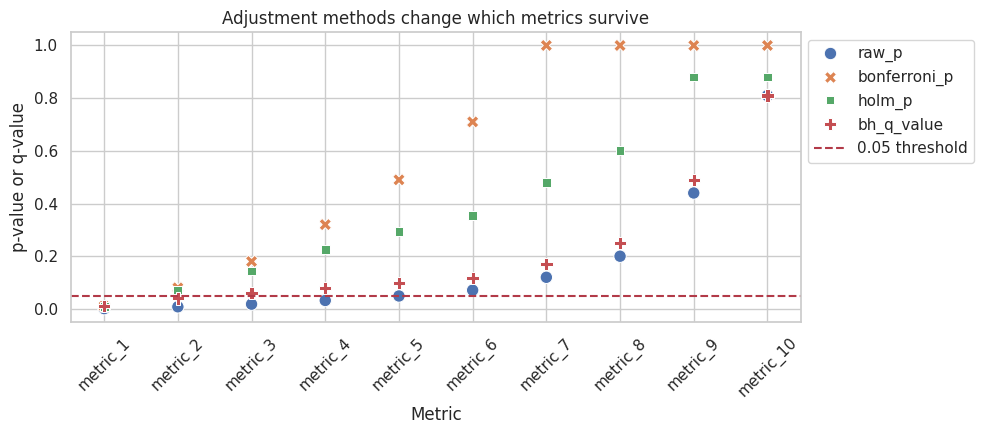

In [10]:
plot_df = example_adjusted.melt(
    id_vars="metric",
    value_vars=["raw_p", "bonferroni_p", "holm_p", "bh_q_value"],
    var_name="method",
    value_name="adjusted_value",
)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.scatterplot(data=plot_df, x="metric", y="adjusted_value", hue="method", style="method", s=80, ax=ax)
ax.axhline(0.05, color="#b23a48", linestyle="--", label="0.05 threshold")
ax.set_title("Adjustment methods change which metrics survive")
ax.set_xlabel("Metric")
ax.set_ylabel("p-value or q-value")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Interpretation

Raw p-values declare many discoveries. Bonferroni is strict. Holm is often slightly less conservative. Benjamini-Hochberg can allow more discoveries because it controls a different quantity: expected false-discovery fraction among rejected tests.

The right method depends on the claim. A launch-critical primary claim should not be treated the same way as an exploratory diagnostic scan.

## 6. Simulating Corrections With True and Null Metrics

Now suppose an experiment has 5 real metric effects and 25 null metrics. We will compare raw p-values, Bonferroni, Holm, and Benjamini-Hochberg in terms of false discoveries and true discoveries.

In [11]:
def simulate_multiple_testing_world(n_experiments=3_000, n_true=5, n_null=25, effect_z=3.0, alpha=0.05, q=0.05, seed=2):
    rng_local = np.random.default_rng(seed)
    rows = []
    m = n_true + n_null
    truth = np.array([1] * n_true + [0] * n_null).astype(bool)
    for _ in range(n_experiments):
        z = np.r_[rng_local.normal(loc=effect_z, scale=1, size=n_true), rng_local.normal(loc=0, scale=1, size=n_null)]
        p = 2 * (1 - stats.norm.cdf(np.abs(z)))
        decisions = {
            "raw_p_lt_0.05": p < alpha,
            "bonferroni": bonferroni_adjust(p) < alpha,
            "holm": holm_adjust(p) < alpha,
            "benjamini_hochberg": bh_reject(p, q=q),
        }
        for method, reject in decisions.items():
            r = reject.sum()
            false_disc = np.logical_and(reject, ~truth).sum()
            true_disc = np.logical_and(reject, truth).sum()
            rows.append({
                "method": method,
                "discoveries": r,
                "true_discoveries": true_disc,
                "false_discoveries": false_disc,
                "any_false_discovery": false_disc > 0,
                "false_discovery_fraction": false_disc / r if r > 0 else 0.0,
            })
    return pd.DataFrame(rows)

mt_sim = simulate_multiple_testing_world()
mt_summary = mt_sim.groupby("method").agg(
    avg_discoveries=("discoveries", "mean"),
    avg_true_discoveries=("true_discoveries", "mean"),
    avg_false_discoveries=("false_discoveries", "mean"),
    prob_any_false_discovery=("any_false_discovery", "mean"),
    avg_false_discovery_fraction=("false_discovery_fraction", "mean"),
).reset_index()
mt_summary.round(3)

,method,avg_discoveries,avg_true_discoveries,avg_false_discoveries,prob_any_false_discovery,avg_false_discovery_fraction
0,benjamini_hochberg,3.147,2.968,0.180,0.156,0.042
1,bonferroni,2.270,2.228,0.042,0.042,0.015
2,holm,2.305,2.262,0.044,0.043,0.016
3,raw_p_lt_0.05,5.518,4.271,1.247,0.723,0.202


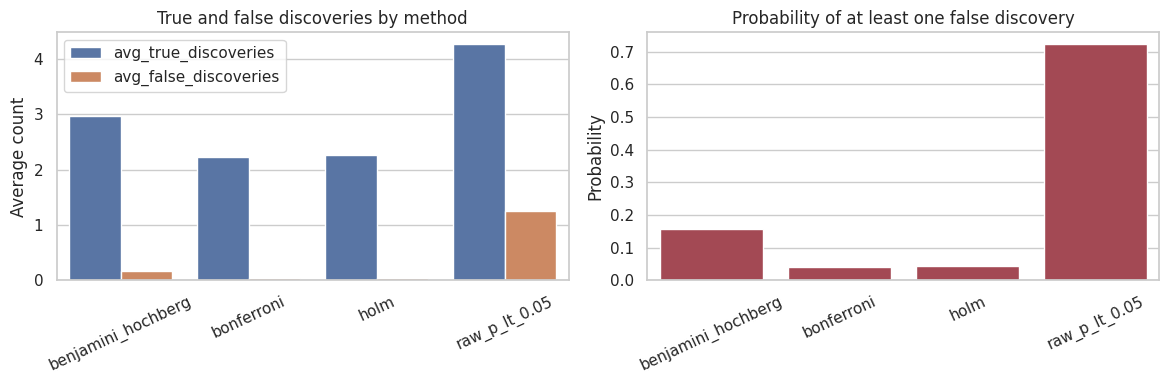

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary_long = mt_summary.melt(
    id_vars="method",
    value_vars=["avg_true_discoveries", "avg_false_discoveries"],
    var_name="discovery_type",
    value_name="average_count",
)
sns.barplot(data=summary_long, x="method", y="average_count", hue="discovery_type", ax=axes[0])
axes[0].set_title("True and false discoveries by method")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average count")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="")

sns.barplot(data=mt_summary, x="method", y="prob_any_false_discovery", color="#b23a48", ax=axes[1])
axes[1].set_title("Probability of at least one false discovery")
axes[1].set_xlabel("")
axes[1].set_ylabel("Probability")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### Interpretation

Raw p-values find more true effects, but they also admit many false positives. Bonferroni and Holm reduce false positives but sacrifice some true discoveries. Benjamini-Hochberg often sits between these goals: more discoveries than FWER methods, while limiting the false-discovery fraction on average.

In product experimentation, this suggests a practical rule:

- Use a strict confirmatory framework for primary decisions and critical guardrails.
- Use FDR-style or explicitly exploratory framing for broad diagnostic scans.

## 7. Correlated Metrics Still Need Discipline

Product metrics are often correlated. Clicks, sessions, active days, revenue, and retention are not independent. Correlation can reduce the effective number of independent tests, but it does not make multiplicity disappear.

Let us simulate null z-statistics with a common factor. Every metric has no true effect, but metric test statistics are correlated.

In [13]:
def simulate_correlated_null_tests(n_experiments=5_000, n_metrics=30, rho=0.5, alpha=0.05, seed=3):
    rng_local = np.random.default_rng(seed)
    common = rng_local.normal(size=(n_experiments, 1))
    noise = rng_local.normal(size=(n_experiments, n_metrics))
    z = np.sqrt(rho) * common + np.sqrt(1 - rho) * noise
    p = 2 * (1 - stats.norm.cdf(np.abs(z)))
    return pd.DataFrame({
        "rho": rho,
        "any_raw_significant": (p < alpha).any(axis=1),
        "number_raw_significant": (p < alpha).sum(axis=1),
        "any_bonferroni_significant": (bonferroni_adjust(p.T).T < alpha).any(axis=1),
    })

rho_results = []
for rho in [0.0, 0.25, 0.50, 0.75, 0.90]:
    sim = simulate_correlated_null_tests(rho=rho)
    rho_results.append({
        "metric_correlation_rho": rho,
        "prob_any_raw_p_lt_0.05": sim["any_raw_significant"].mean(),
        "avg_number_raw_p_lt_0.05": sim["number_raw_significant"].mean(),
        "prob_any_bonferroni": sim["any_bonferroni_significant"].mean(),
    })
rho_table = pd.DataFrame(rho_results)
rho_table.round(3)

,metric_correlation_rho,prob_any_raw_p_lt_0.05,avg_number_raw_p_lt_0.05,prob_any_bonferroni
0,0.00,0.784,1.478,0.047
1,0.25,0.699,1.512,0.043
2,0.50,0.519,1.535,0.033
3,0.75,0.309,1.514,0.018
4,0.90,0.178,1.512,0.011


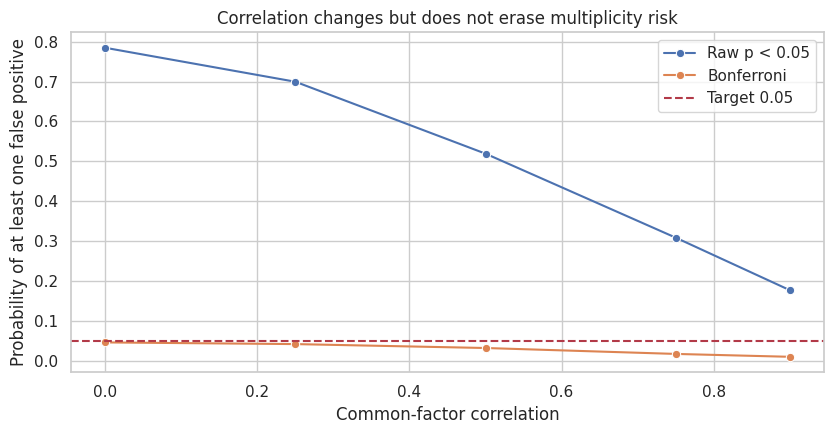

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.lineplot(data=rho_table, x="metric_correlation_rho", y="prob_any_raw_p_lt_0.05", marker="o", label="Raw p < 0.05", ax=ax)
sns.lineplot(data=rho_table, x="metric_correlation_rho", y="prob_any_bonferroni", marker="o", label="Bonferroni", ax=ax)
ax.axhline(0.05, color="#b23a48", linestyle="--", label="Target 0.05")
ax.set_title("Correlation changes but does not erase multiplicity risk")
ax.set_xlabel("Common-factor correlation")
ax.set_ylabel("Probability of at least one false positive")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

Highly correlated metrics behave less like 30 independent tests, but raw metric scanning still has elevated false-positive risk. In practice, metric correlation is rarely known well enough to justify casual cherry-picking. Pre-specification is cleaner than arguing after the fact that the metrics were correlated anyway.

## 8. Guardrail Metrics as Launch Constraints

A guardrail metric asks whether the treatment harmed something important. The goal is not always to discover every tiny guardrail movement. The goal is to avoid launching when harm exceeds a pre-specified tolerance.

For example:

- latency must not increase by more than 5 ms;
- crash rate must not increase by more than 0.05 percentage points;
- refund rate must not increase by more than 0.10 percentage points;
- support ticket rate must not increase by more than 0.20 percentage points.

A practical guardrail rule can use confidence intervals:

> Pass the guardrail if the upper confidence bound on harm is below the tolerance.

This turns guardrails into decision constraints rather than a pile of unstructured p-values.

In [15]:
def simulate_product_metric_table(n=50_000, seed=4):
    rng_local = np.random.default_rng(seed)
    z = rng_local.binomial(1, 0.5, size=n)
    pre_value = rng_local.lognormal(mean=2.0, sigma=0.6, size=n)
    user_intensity = rng_local.gamma(shape=2.0, scale=1.0, size=n)

    primary = 18 + 0.35 * z + 1.4 * np.log1p(pre_value) + rng_local.normal(scale=5.0, size=n)
    activation = 0.40 + 0.012 * z + 0.04 * np.log1p(pre_value) + rng_local.normal(scale=0.20, size=n)
    sessions = 3.0 + 0.04 * z + 0.45 * user_intensity + rng_local.normal(scale=1.1, size=n)
    latency = 180 + 4.2 * z + 8 * rng_local.normal(size=n)
    error_rate = rng_local.binomial(1, np.clip(0.018 + 0.0015 * z, 0, 1), size=n)
    support_ticket = rng_local.binomial(1, np.clip(0.035 + 0.0025 * z, 0, 1), size=n)
    pre_invariant = pre_value
    country_numeric = rng_local.normal(loc=0, scale=1, size=n)  # stand-in for pre-treatment mix checks

    return pd.DataFrame({
        "Z": z,
        "primary_value": primary,
        "activation_score": activation,
        "sessions_per_user": sessions,
        "latency_ms": latency,
        "error_rate": error_rate,
        "support_ticket_rate": support_ticket,
        "pre_value_invariant": pre_invariant,
        "country_mix_score": country_numeric,
    })

product_df = simulate_product_metric_table()
metric_specs = pd.DataFrame([
    {"metric": "primary_value", "role": "primary", "higher_is_better": True, "practical_threshold": 0.20, "guardrail_tolerance": np.nan},
    {"metric": "activation_score", "role": "secondary", "higher_is_better": True, "practical_threshold": np.nan, "guardrail_tolerance": np.nan},
    {"metric": "sessions_per_user", "role": "secondary", "higher_is_better": True, "practical_threshold": np.nan, "guardrail_tolerance": np.nan},
    {"metric": "latency_ms", "role": "guardrail", "higher_is_better": False, "practical_threshold": np.nan, "guardrail_tolerance": 5.0},
    {"metric": "error_rate", "role": "guardrail", "higher_is_better": False, "practical_threshold": np.nan, "guardrail_tolerance": 0.003},
    {"metric": "support_ticket_rate", "role": "guardrail", "higher_is_better": False, "practical_threshold": np.nan, "guardrail_tolerance": 0.004},
    {"metric": "pre_value_invariant", "role": "invariant", "higher_is_better": True, "practical_threshold": np.nan, "guardrail_tolerance": np.nan},
    {"metric": "country_mix_score", "role": "invariant", "higher_is_better": True, "practical_threshold": np.nan, "guardrail_tolerance": np.nan},
])

rows = []
for spec in metric_specs.itertuples(index=False):
    diff, se, p = two_sample_summary(product_df[spec.metric], product_df["Z"])
    rows.append(make_metric_result(
        metric=spec.metric,
        role=spec.role,
        diff=diff,
        se=se,
        p_value=p,
        higher_is_better=spec.higher_is_better,
        practical_threshold=None if pd.isna(spec.practical_threshold) else spec.practical_threshold,
        guardrail_tolerance=None if pd.isna(spec.guardrail_tolerance) else spec.guardrail_tolerance,
    ))
metric_results = pd.DataFrame(rows)
metric_results["bonferroni_p_within_all"] = bonferroni_adjust(metric_results["p_value"])
metric_results["bh_q_within_all"] = bh_adjust(metric_results["p_value"])
metric_results.round(4)

,metric,role,difference,std_error,ci_lower,ci_upper,p_value,higher_is_better,practical_threshold,guardrail_tolerance,bonferroni_p_within_all,bh_q_within_all
0,primary_value,primary,0.3617,0.0451,0.2732,0.4501,0.0000,True,0.2,NaN,0.0000,0.0000
1,activation_score,secondary,0.0092,0.0018,0.0057,0.0128,0.0000,True,NaN,NaN,0.0000,0.0000
2,sessions_per_user,secondary,0.0253,0.0114,0.0030,0.0476,0.0263,True,NaN,NaN,0.2103,0.0421
3,latency_ms,guardrail,4.2867,0.0715,4.1465,4.4269,0.0000,False,NaN,5.000,0.0000,0.0000
4,error_rate,guardrail,0.0047,0.0012,0.0023,0.0072,0.0001,False,NaN,0.003,0.0011,0.0003
5,support_ticket_rate,guardrail,0.0019,0.0017,-0.0013,0.0052,0.2473,False,NaN,0.004,1.0000,0.2891
6,pre_value_invariant,invariant,0.0380,0.0521,-0.0641,0.1401,0.4657,True,NaN,NaN,1.0000,0.4657
7,country_mix_score,invariant,-0.0103,0.0090,-0.0279,0.0073,0.2529,True,NaN,NaN,1.0000,0.2891


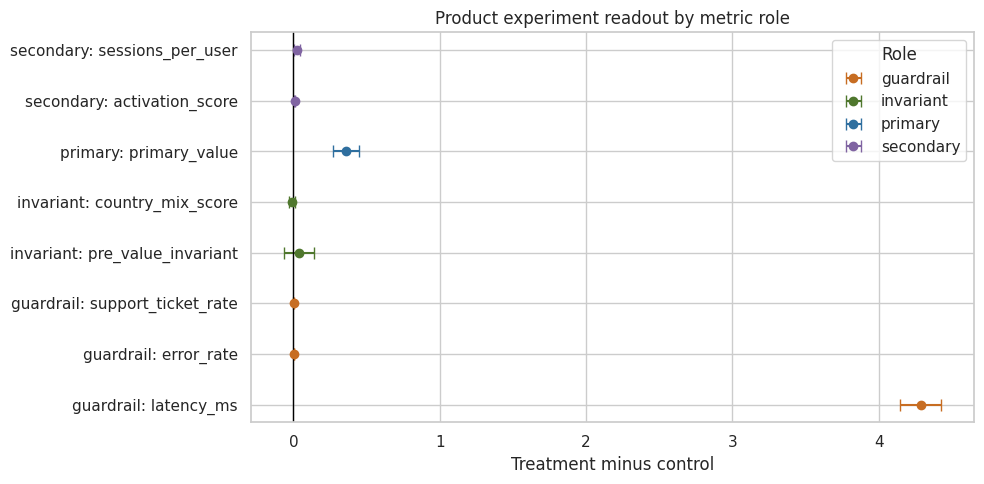

In [16]:
plot_df = metric_results.copy()
plot_df["label"] = plot_df["role"] + ": " + plot_df["metric"]
role_palette = {
    "primary": "#2f6f9f",
    "secondary": "#8064a2",
    "guardrail": "#c76d22",
    "invariant": "#4f772d",
}

fig, ax = plt.subplots(figsize=(10, 5))
for role, g in plot_df.groupby("role"):
    ax.errorbar(
        g["difference"],
        g["label"],
        xerr=[g["difference"] - g["ci_lower"], g["ci_upper"] - g["difference"]],
        fmt="o",
        color=role_palette[role],
        capsize=4,
        label=role,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Product experiment readout by metric role")
ax.set_xlabel("Treatment minus control")
ax.set_ylabel("")
ax.legend(title="Role")
plt.tight_layout()
plt.show()

### Interpretation

The primary metric improved. Some secondary metrics moved. Latency increased, but the guardrail question is not simply whether latency moved. The question is whether the increase exceeds the pre-specified tolerance.

For guardrails, a confidence-bound rule is often more decision-relevant than a generic two-sided p-value. A tiny latency increase can be statistically significant in a huge experiment but operationally acceptable; a large but noisy increase may require caution even if $p > 0.05$.

In [17]:
def evaluate_metric_decisions(results):
    rows = []
    for r in results.itertuples(index=False):
        if r.role == "primary":
            passes = r.ci_lower > r.practical_threshold
            rule = f"CI lower > practical threshold ({r.practical_threshold})"
        elif r.role == "guardrail":
            # For bad-is-higher guardrails, harm is treatment-control increase.
            passes = r.ci_upper < r.guardrail_tolerance
            rule = f"CI upper < harm tolerance ({r.guardrail_tolerance})"
        elif r.role == "invariant":
            passes = r.p_value > 0.01
            rule = "No strong evidence of movement (p > 0.01)"
        else:
            passes = np.nan
            rule = "Exploratory / diagnostic"
        rows.append({
            "metric": r.metric,
            "role": r.role,
            "difference": r.difference,
            "ci_lower": r.ci_lower,
            "ci_upper": r.ci_upper,
            "p_value": r.p_value,
            "decision_rule": rule,
            "passes_rule": passes,
        })
    return pd.DataFrame(rows)

decision_table = evaluate_metric_decisions(metric_results)
decision_table.round(4)

,metric,role,difference,ci_lower,ci_upper,p_value,decision_rule,passes_rule
0,primary_value,primary,0.3617,0.2732,0.4501,0.0000,CI lower > practical threshold (0.2),True
1,activation_score,secondary,0.0092,0.0057,0.0128,0.0000,Exploratory / diagnostic,NaN
2,sessions_per_user,secondary,0.0253,0.0030,0.0476,0.0263,Exploratory / diagnostic,NaN
3,latency_ms,guardrail,4.2867,4.1465,4.4269,0.0000,CI upper < harm tolerance (5.0),True
4,error_rate,guardrail,0.0047,0.0023,0.0072,0.0001,CI upper < harm tolerance (0.003),False
5,support_ticket_rate,guardrail,0.0019,-0.0013,0.0052,0.2473,CI upper < harm tolerance (0.004),False
6,pre_value_invariant,invariant,0.0380,-0.0641,0.1401,0.4657,No strong evidence of movement (p > 0.01),True
7,country_mix_score,invariant,-0.0103,-0.0279,0.0073,0.2529,No strong evidence of movement (p > 0.01),True


### Interpretation

The experiment does not reduce to one p-value. The launch recommendation depends on whether the primary metric clears the practical threshold and whether guardrails remain within tolerance.

This is a stronger habit than treating all metrics as equal. Equal treatment of unequal metrics invites either overreaction or cherry-picking.

## 9. Segment Fishing

Segment analysis is useful when it is pre-specified or used to generate hypotheses. It becomes dangerous when a team scans many segments after the experiment and elevates the most exciting result.

Let us simulate an experiment with no treatment effect in any segment. We will still find impressive-looking segment effects if we search enough segments.

In [18]:
def simulate_segment_fishing(n_experiments=3_000, n_segments=40, users_per_segment=400, sigma=5.0, seed=5):
    rng_local = np.random.default_rng(seed)
    rows = []
    for exp in range(n_experiments):
        estimates = []
        pvals = []
        for seg in range(n_segments):
            z = rng_local.binomial(1, 0.5, size=users_per_segment)
            y = rng_local.normal(0, sigma, size=users_per_segment)  # no effect anywhere
            diff, se, p = two_sample_summary(y, z)
            estimates.append(diff)
            pvals.append(p)
        estimates = np.array(estimates)
        pvals = np.array(pvals)
        best_idx = np.argmax(np.abs(estimates))
        rows.append({
            "experiment": exp,
            "max_abs_segment_effect": np.abs(estimates[best_idx]),
            "best_segment_effect": estimates[best_idx],
            "best_segment_p": pvals[best_idx],
            "any_segment_p_lt_0.05": (pvals < 0.05).any(),
            "bonferroni_any": (bonferroni_adjust(pvals) < 0.05).any(),
            "bh_any": bh_reject(pvals, q=0.05).any(),
        })
    return pd.DataFrame(rows)

segment_fishing = simulate_segment_fishing()
segment_summary = pd.DataFrame({
    "quantity": [
        "Probability any raw segment p < 0.05",
        "Probability any Bonferroni-adjusted segment survives",
        "Probability any BH segment survives",
        "Median largest absolute segment estimate",
        "95th percentile largest absolute segment estimate",
    ],
    "value": [
        segment_fishing["any_segment_p_lt_0.05"].mean(),
        segment_fishing["bonferroni_any"].mean(),
        segment_fishing["bh_any"].mean(),
        segment_fishing["max_abs_segment_effect"].median(),
        segment_fishing["max_abs_segment_effect"].quantile(0.95),
    ],
})
segment_summary.round(4)

,quantity,value
0,Probability any raw segment p < 0.05,0.8763
1,Probability any Bonferroni-adjusted segment su...,0.0510
2,Probability any BH segment survives,0.0530
3,Median largest absolute segment estimate,1.1932
4,95th percentile largest absolute segment estimate,1.6107


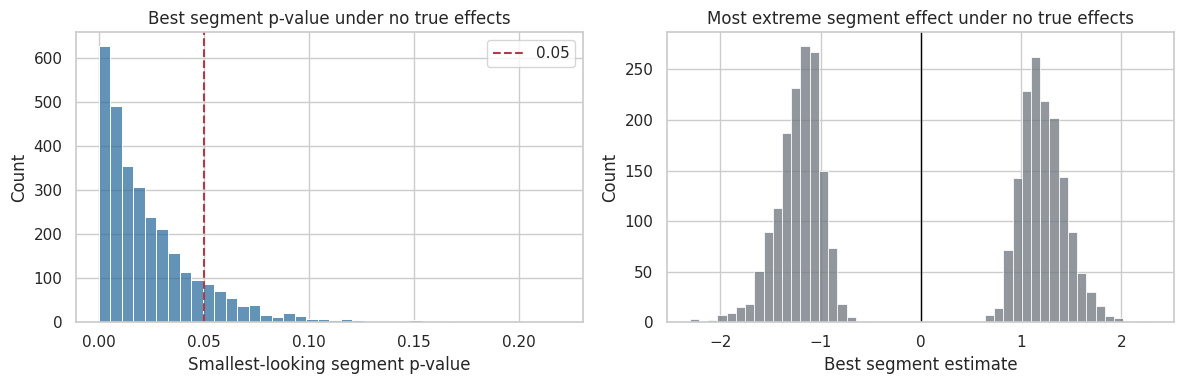

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(segment_fishing["best_segment_p"], bins=40, color="#2f6f9f", ax=axes[0])
axes[0].axvline(0.05, color="#b23a48", linestyle="--", label="0.05")
axes[0].set_title("Best segment p-value under no true effects")
axes[0].set_xlabel("Smallest-looking segment p-value")
axes[0].legend()

sns.histplot(segment_fishing["best_segment_effect"], bins=50, color="#6c757d", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Most extreme segment effect under no true effects")
axes[1].set_xlabel("Best segment estimate")

plt.tight_layout()
plt.show()

### Interpretation

The best-looking segment often looks meaningful even when every segment effect is truly zero. This is why subgroup claims should be handled carefully.

A practical workflow:

- Pre-specify a small number of high-value segments for confirmatory analysis.
- Treat broad segment scans as exploratory.
- Use FDR control or shrinkage methods for large discovery scans.
- Confirm surprising segment findings in a follow-up experiment or holdout period.

## 10. One Primary Metric, Many Diagnostics

A clean experiment readout can still include many diagnostics. The key is to separate confirmatory and exploratory claims.

A common hierarchy:

1. **Primary metric**: one metric or a small pre-specified family. This drives the headline conclusion.
2. **Guardrails**: pre-specified harm thresholds. These constrain launch.
3. **Invariants**: quality checks. These determine whether the data are trustworthy.
4. **Secondary metrics**: pre-specified mechanism metrics. These explain movement.
5. **Exploratory diagnostics**: broad scans. These create hypotheses, not launch claims.

This hierarchy makes it harder to fool ourselves and easier for stakeholders to read the result.

In [20]:
metric_hierarchy = pd.DataFrame({
    "tier": [
        "Primary",
        "Guardrail",
        "Invariant",
        "Secondary",
        "Exploratory diagnostic",
    ],
    "example": [
        "14-day retained value",
        "Latency, crash rate, refund rate",
        "Pre-experiment value, country mix, assignment share",
        "Activation, sessions, onboarding completion",
        "50 segments x 20 funnel metrics",
    ],
    "claim_allowed": [
        "Confirmatory launch claim",
        "Launch constraint / safety claim",
        "Trust or data-quality claim",
        "Mechanism support if pre-specified",
        "Hypothesis generation only unless adjusted and validated",
    ],
    "typical_error_strategy": [
        "Single test or small FWER-controlled family",
        "Confidence-bound tolerance rules; FWER for critical families",
        "Strict anomaly thresholds and investigation",
        "Report with context; adjust if many are confirmatory",
        "FDR control, shrinkage, or follow-up experiment",
    ],
})
metric_hierarchy

,tier,example,claim_allowed,typical_error_strategy
0,Primary,14-day retained value,Confirmatory launch claim,Single test or small FWER-controlled family
1,Guardrail,"Latency, crash rate, refund rate",Launch constraint / safety claim,Confidence-bound tolerance rules; FWER for cri...
2,Invariant,"Pre-experiment value, country mix, assignment ...",Trust or data-quality claim,Strict anomaly thresholds and investigation
3,Secondary,"Activation, sessions, onboarding completion",Mechanism support if pre-specified,Report with context; adjust if many are confir...
4,Exploratory diagnostic,50 segments x 20 funnel metrics,Hypothesis generation only unless adjusted and...,"FDR control, shrinkage, or follow-up experiment"


## 11. Metric Families and Adjustment Scope

A subtle but important choice is the **family** of tests. A family is the set of tests over which an error rate is controlled.

Examples:

- all primary outcome variants;
- all guardrail safety metrics;
- all country-level segment tests;
- all exploratory funnel diagnostics;
- every metric in the dashboard.

Controlling across every dashboard metric can be overly conservative. Controlling nothing can be misleading. The family should match the claim.

If the claim is "the primary metric improved," the primary family matters. If the claim is "there is a segment-specific win in France," the segment scan family matters. If the claim is "nothing important was harmed," the guardrail family matters.

In [21]:
families = pd.DataFrame({
    "claim": [
        "The feature improved the primary business metric",
        "The feature did not violate safety/performance guardrails",
        "The effect is strongest in one discovered segment",
        "Several funnel steps improved",
        "The experiment data are trustworthy",
    ],
    "relevant_family": [
        "Primary metric family",
        "Guardrail family",
        "All scanned segment tests",
        "All funnel metrics treated as confirmatory",
        "Invariant and quality checks",
    ],
    "reasonable_strategy": [
        "Pre-specify one metric or control FWER for a small primary family",
        "Use harm tolerances; strict control for critical guardrails",
        "Label exploratory or apply FDR/holdout confirmation",
        "Adjust or label as directional mechanism evidence",
        "Investigate anomalies rather than launch from them",
    ],
})
families

,claim,relevant_family,reasonable_strategy
0,The feature improved the primary business metric,Primary metric family,Pre-specify one metric or control FWER for a s...
1,The feature did not violate safety/performance...,Guardrail family,Use harm tolerances; strict control for critic...
2,The effect is strongest in one discovered segment,All scanned segment tests,Label exploratory or apply FDR/holdout confirm...
3,Several funnel steps improved,All funnel metrics treated as confirmatory,Adjust or label as directional mechanism evidence
4,The experiment data are trustworthy,Invariant and quality checks,Investigate anomalies rather than launch from ...


## 12. Building a Product Decision Readout

Let us combine the pieces into a launch-style readout.

Decision rule for this simulated experiment:

- Primary metric passes if the 95% CI lower bound exceeds the practical threshold of 0.20.
- Latency passes if the 95% CI upper bound is below 5 ms harm.
- Error rate passes if the upper bound is below 0.003 absolute harm.
- Support tickets pass if the upper bound is below 0.004 absolute harm.
- Invariants pass if they show no strong anomaly.
- Secondary metrics are reported as mechanism evidence, not launch conditions.

In [22]:
primary_pass = bool(decision_table.query("role == 'primary'")["passes_rule"].all())
guardrail_pass = bool(decision_table.query("role == 'guardrail'")["passes_rule"].all())
invariant_pass = bool(decision_table.query("role == 'invariant'")["passes_rule"].all())
recommendation = "Launch" if primary_pass and guardrail_pass and invariant_pass else "Do not launch yet / iterate"

readout_summary = pd.DataFrame({
    "component": [
        "Recommendation",
        "Primary metric",
        "Guardrails",
        "Invariants",
        "Secondary metrics",
        "Exploratory scans",
    ],
    "readout": [
        recommendation,
        "Passes practical threshold" if primary_pass else "Does not clear practical threshold",
        "All guardrails pass" if guardrail_pass else "At least one guardrail needs attention",
        "No strong invariant anomaly" if invariant_pass else "Investigate invariant anomaly",
        "Use for mechanism interpretation",
        "Treat as hypothesis generation unless adjusted/confirmed",
    ],
})
readout_summary

,component,readout
0,Recommendation,Do not launch yet / iterate
1,Primary metric,Passes practical threshold
2,Guardrails,At least one guardrail needs attention
3,Invariants,No strong invariant anomaly
4,Secondary metrics,Use for mechanism interpretation
5,Exploratory scans,Treat as hypothesis generation unless adjusted...


In [23]:
compact = decision_table.copy()
compact["status"] = np.where(compact["passes_rule"] == True, "pass", np.where(compact["passes_rule"] == False, "attention", "exploratory"))
compact[["metric", "role", "difference", "ci_lower", "ci_upper", "p_value", "decision_rule", "status"]].round(4)

,metric,role,difference,ci_lower,ci_upper,p_value,decision_rule,status
0,primary_value,primary,0.3617,0.2732,0.4501,0.0000,CI lower > practical threshold (0.2),pass
1,activation_score,secondary,0.0092,0.0057,0.0128,0.0000,Exploratory / diagnostic,exploratory
2,sessions_per_user,secondary,0.0253,0.0030,0.0476,0.0263,Exploratory / diagnostic,exploratory
3,latency_ms,guardrail,4.2867,4.1465,4.4269,0.0000,CI upper < harm tolerance (5.0),pass
4,error_rate,guardrail,0.0047,0.0023,0.0072,0.0001,CI upper < harm tolerance (0.003),attention
5,support_ticket_rate,guardrail,0.0019,-0.0013,0.0052,0.2473,CI upper < harm tolerance (0.004),attention
6,pre_value_invariant,invariant,0.0380,-0.0641,0.1401,0.4657,No strong evidence of movement (p > 0.01),pass
7,country_mix_score,invariant,-0.0103,-0.0279,0.0073,0.2529,No strong evidence of movement (p > 0.01),pass


### Interpretation

This table is much more useful than a list sorted by p-value. It tells stakeholders what the experiment was designed to decide, whether the launch constraints were satisfied, and what should be treated as exploratory.

A p-value-sorted dashboard is a discovery tool. A metric hierarchy is a decision tool.

## 13. Common Mistakes

### Mistake 1: Treating all metrics as equal

Primary, guardrail, invariant, and diagnostic metrics answer different questions. They should not be combined into one undifferentiated p-value list.

### Mistake 2: Promoting exploratory findings after seeing the data

If a segment or metric was discovered after scanning dozens of possibilities, it needs adjustment, replication, or clear exploratory labeling.

### Mistake 3: Ignoring guardrail tolerances

A statistically significant latency increase may be operationally irrelevant. A non-significant but large potential harm may still be risky. Guardrails need practical tolerances.

### Mistake 4: Overcorrecting every dashboard metric

Correction scope should match the claim. Do not make the primary launch decision hostage to hundreds of exploratory diagnostics, but do not claim exploratory diagnostics as confirmatory evidence.

### Mistake 5: Forgetting power after adjustment

Multiple-testing correction reduces false positives but can also reduce power. If a family of guardrails or outcomes is confirmatory, plan sample size accordingly.

## 14. Key Takeaways

- Many metrics create many chances for false positives.
- The probability of at least one false positive grows quickly with the number of tests.
- A metric hierarchy separates decision metrics, guardrails, invariants, secondary metrics, and exploratory diagnostics.
- Bonferroni and Holm-style methods control familywise error and are useful for confirmatory families.
- Benjamini-Hochberg controls false discovery rate and is useful for broader exploratory scans.
- Guardrail decisions should use practical harm tolerances, not only generic two-sided p-values.
- Segment scans are powerful hypothesis generators but weak confirmatory evidence unless pre-specified or adjusted.
- The family of tests should match the claim being made.

The next experiments notebook will cover clustered experiments: what changes when users are not independent, treatment is assigned at a group level, or outcomes are correlated within markets, schools, stores, accounts, or networks.

## References

Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery rate: A practical and powerful approach to multiple testing. *Journal of the Royal Statistical Society Series B: Statistical Methodology, 57*(1), 289-300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x

Crook, T. R., Frasca, B., Kohavi, R., & Longbotham, R. (2009). Seven pitfalls to avoid when running controlled experiments on the web. *Proceedings of the 15th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1105-1114. https://doi.org/10.1145/1557019.1557139

Donoghue, J. R. (2004). Implementing Shaffer's multiple comparison procedure for a large number of groups. *Lecture Notes-Monograph Series*, 1-23. https://doi.org/10.1214/lnms/1196285622

Kohavi, R., Longbotham, R., Sommerfield, D., & Henne, R. M. (2008). Controlled experiments on the web: Survey and practical guide. *Data Mining and Knowledge Discovery, 18*(1), 140-181. https://doi.org/10.1007/s10618-008-0114-1

Mattos, D. I., Dmitriev, P., Fabijan, A., & Bosch, J. (2018). An activity and metric model for online controlled experiments. *Lecture Notes in Business Information Processing*, 182-198. https://doi.org/10.1007/978-3-030-03673-7_14

Thissen, D., Steinberg, L., & Kuang, D. (2002). Quick and easy implementation of the Benjamini-Hochberg procedure for controlling the false positive rate in multiple comparisons. *Journal of Educational and Behavioral Statistics, 27*(1), 77-83. https://doi.org/10.3102/10769986027001077

Verhoeven, K. J. F., Simonsen, K. L., & McIntyre, L. M. (2005). Implementing false discovery rate control: Increasing your power. *Oikos, 108*(3), 643-647. https://doi.org/10.1111/j.0030-1299.2005.13727.x

Xie, Y., Xu, M., & Chow, E. (2020). How to measure your app: A couple of pitfalls and remedies in measuring app performance in online controlled experiments. *arXiv*. https://doi.org/10.48550/arxiv.2011.14437